Choosing from all possible events


Device: cpu
Loading data...
Data shape: (576, 22, 513)
Classes: ['feet' 'left_hand' 'right_hand' 'tongue']
Number of samples: 576
Class mapping: {np.str_('feet'): np.int64(0), np.str_('left_hand'): np.int64(1), np.str_('right_hand'): np.int64(2), np.str_('tongue'): np.int64(3)}

===== Fold 1 =====
  Epoch 20/100 - loss: 0.7309
  Epoch 40/100 - loss: 0.6059
  Epoch 60/100 - loss: 0.5344
  Epoch 80/100 - loss: 0.4691
  Epoch 100/100 - loss: 0.4026
  Accuracy : 0.8190
  Kappa    : 0.7586
  F1 (macro): 0.8142
  Precision : 0.8205
  ITR      : 15.46 bits/min

===== Fold 2 =====
  Epoch 20/100 - loss: 0.6945
  Epoch 40/100 - loss: 0.5606
  Epoch 60/100 - loss: 0.4878
  Epoch 80/100 - loss: 0.4229
  Epoch 100/100 - loss: 0.3916
  Accuracy : 0.7478
  Kappa    : 0.6636
  F1 (macro): 0.7384
  Precision : 0.7638
  ITR      : 11.78 bits/min

===== Fold 3 =====
  Epoch 20/100 - loss: 0.8121
  Epoch 40/100 - loss: 0.6238
  Epoch 60/100 - loss: 0.5348
  Epoch 80/100 - loss: 0.4876
  Epoch 100/100 - l

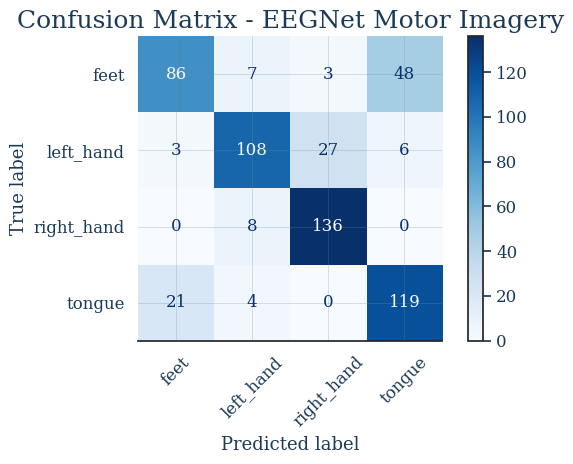


Saved: confusion_matrix.png


In [1]:
# ============================================================
# EEG Motor Imagery Classification with EEGNet
# Dataset: BNCI2014_001 (BCI Competition IV 2a) via MOABB
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             cohen_kappa_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# MOABB for automatic dataset loading
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ============================================================
# 1. Load data with MOABB
# ============================================================
# MOABB downloads and prepares the dataset automatically.
dataset = BNCI2014_001()

# The paradigm defines which kind of signal we want.
# fmin/fmax: band-pass filter over mu and beta bands.
# resample: downsample to 128 Hz to make the model lighter.
paradigm = MotorImagery(
    n_classes=4,
    fmin=8,
    fmax=30,
    resample=128
)

# X: EEG signals with shape (n_trials, n_channels, n_times)
# y: class labels (left_hand, right_hand, feet, tongue)
# metadata: extra info (session, run, subject)
print("Loading data...")
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])

print(f"Data shape: {X.shape}")      # e.g. (288, 22, 257)
print(f"Classes: {np.unique(y)}")
print(f"Number of samples: {len(y)}")

# ============================================================
# 2. Preprocessing: per-epoch normalization
# ============================================================
# Normalize each epoch independently so the model is not
# sensitive to the absolute scale of the signal.
def normalize_epochs(X):
    # X shape: (trials, channels, times)
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True) + 1e-8
    return (X - mean) / std

X = normalize_epochs(X)

# Convert text labels to integers.
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ============================================================
# 3. EEGNet architecture
# ============================================================
# EEGNet is a lightweight CNN with two main blocks:
# Block 1: Temporal Conv -> Depthwise Conv -> BN -> Activation -> Pool
# Block 2: Separable Conv -> BN -> Activation -> Pool
# Head: Flatten -> Dense -> Softmax (via CrossEntropyLoss)

class EEGNet(nn.Module):
    def __init__(self, n_classes, n_channels, n_times,
                 F1=8, D=2, F2=16, dropout=0.5):
        """
        F1: number of temporal filters
        D:  depth multiplier for the depthwise conv
        F2: number of separable filters (should equal F1*D)
        """
        super().__init__()

        # ---- Block 1: learn temporal patterns ----
        self.block1 = nn.Sequential(
            # Temporal convolution: filters along the time axis.
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
            # Depthwise convolution: learns a spatial filter per feature map,
            # combining information across EEG channels.
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            # Average pooling reduces the time dimension.
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        # ---- Block 2: separable convolution ----
        self.block2 = nn.Sequential(
            # Depthwise part of the separable conv (temporal).
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16),
                      padding=(0, 8), groups=F1 * D, bias=False),
            # Pointwise part (1x1) mixes the feature maps.
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        # Infer the flattened feature size with a dummy forward pass.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out = self.block2(self.block1(dummy))
            self.flat_dim = out.numel()

        # Classification head.
        self.classifier = nn.Linear(self.flat_dim, n_classes)

    def forward(self, x):
        # x shape: (batch, 1, channels, times)
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)   # flatten
        return self.classifier(x)   # raw logits

# ============================================================
# 4. Training and evaluation helpers
# ============================================================
def train_one_fold(model, train_loader, val_loader, epochs=100, lr=1e-3):
    """Train a single fold and return the trained model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(epochs):
        # ---- training phase ----
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # print progress every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - loss: {total_loss/len(train_loader):.4f}")

    return model


def evaluate(model, loader):
    """Run inference and collect predictions and true labels."""
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())
    return np.array(all_true), np.array(all_preds)


# ============================================================
# 5. ITR (Information Transfer Rate)
# ============================================================
def compute_itr(accuracy, n_classes, trial_time_sec):
    """
    ITR in bits/min.
    accuracy:       classification accuracy (0..1)
    n_classes:      number of possible commands (N)
    trial_time_sec: time to produce one command, in seconds
    """
    P = accuracy
    N = n_classes

    # bits per trial (Wolpaw formula)
    if P <= 0:
        bits = 0.0
    elif P >= 1:
        bits = np.log2(N)
    else:
        bits = (np.log2(N)
                + P * np.log2(P)
                + (1 - P) * np.log2((1 - P) / (N - 1)))

    # convert bits/trial to bits/min
    trials_per_min = 60.0 / trial_time_sec
    return bits * trials_per_min


# ============================================================
# 6. Cross-validation loop
# ============================================================
n_channels = X.shape[1]
n_times = X.shape[2]
n_classes = len(np.unique(y_encoded))

# Add the channel dimension expected by Conv2d: (trials, 1, channels, times)
X_torch = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
y_torch = torch.tensor(y_encoded, dtype=torch.long)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_metrics = []
all_true_global, all_pred_global = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_encoded), 1):
    print(f"\n===== Fold {fold} =====")

    train_ds = TensorDataset(X_torch[train_idx], y_torch[train_idx])
    val_ds = TensorDataset(X_torch[val_idx], y_torch[val_idx])
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    model = EEGNet(n_classes, n_channels, n_times).to(DEVICE)
    model = train_one_fold(model, train_loader, val_loader, epochs=100)

    y_true, y_pred = evaluate(model, val_loader)
    all_true_global.extend(y_true)
    all_pred_global.extend(y_pred)

    # ---- metrics for this fold ----
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro')

    # Trial time = motor imagery window (~4 s in this dataset).
    itr = compute_itr(acc, n_classes, trial_time_sec=4.0)

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Kappa    : {kappa:.4f}")
    print(f"  F1 (macro): {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  ITR      : {itr:.2f} bits/min")

    fold_metrics.append({
        'accuracy': acc, 'kappa': kappa,
        'f1': f1, 'precision': prec, 'itr': itr
    })

# ============================================================
# 7. Aggregate results
# ============================================================
print("\n===== Average across folds =====")
for key in ['accuracy', 'kappa', 'f1', 'precision', 'itr']:
    vals = [m[key] for m in fold_metrics]
    print(f"  {key:10s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")

# ============================================================
# 8. Confusion matrix over all folds
# ============================================================
cm = confusion_matrix(all_true_global, all_pred_global)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - EEGNet Motor Imagery")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("\nSaved: confusion_matrix.png")
